In [ ]:
from environment import Environment
from collections import defaultdict
import pandas as pd
import random
import numpy as np
import os
os.chdir(os.path.dirname(os.getcwd()))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N = 50000
N_UPDATES = 200          # number of update steps per sample
BATCH_SIZE = 1000
csv_path = "samples.csv"
updates_csv_path = "impact_updates.csv"

environment = Environment()
header_written = os.path.exists(csv_path)
updates_header_written = os.path.exists(updates_csv_path)

batch = defaultdict(list)
updates_batch = defaultdict(list)

for i in range(N):
    # --------------- Sampling
    environment.sample_features()
    environment.update_derived()

    # --------------- Saving samples
    for key, value in environment.samples.features.items():
        if key not in ("season", "geometry"):
            batch[key].append(value)

    for key, value in environment.derived.items():
        batch[key].append(value)

    batch["impact"].append(environment.impact)

    # --------------- Update steps — track how impact evolves
    updates_batch["sample_id"].append(i)
    updates_batch["update_0"].append(environment.impact)  # baseline before any updates

    for step in range(1, N_UPDATES + 1):
        environment.update_features()
        updates_batch[f"update_{step}"].append(environment.impact)

    # --------------- Flush to disk every BATCH_SIZE iterations
    if (i + 1) % BATCH_SIZE == 0:
        print(f"Batch {(i + 1) // BATCH_SIZE}")

        df = pd.DataFrame(batch)
        df.to_csv(csv_path, mode="a", index=False, header=not header_written)
        header_written = True
        batch = defaultdict(list)

        updates_df = pd.DataFrame(updates_batch)
        updates_df.to_csv(updates_csv_path, mode="a", index=False, header=not updates_header_written)
        updates_header_written = True
        updates_batch = defaultdict(list)

# Write any remaining rows
if batch:
    df = pd.DataFrame(batch)
    df.to_csv(csv_path, mode="a", index=False, header=not header_written)

if updates_batch:
    updates_df = pd.DataFrame(updates_batch)
    updates_df.to_csv(updates_csv_path, mode="a", index=False, header=not updates_header_written)

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50


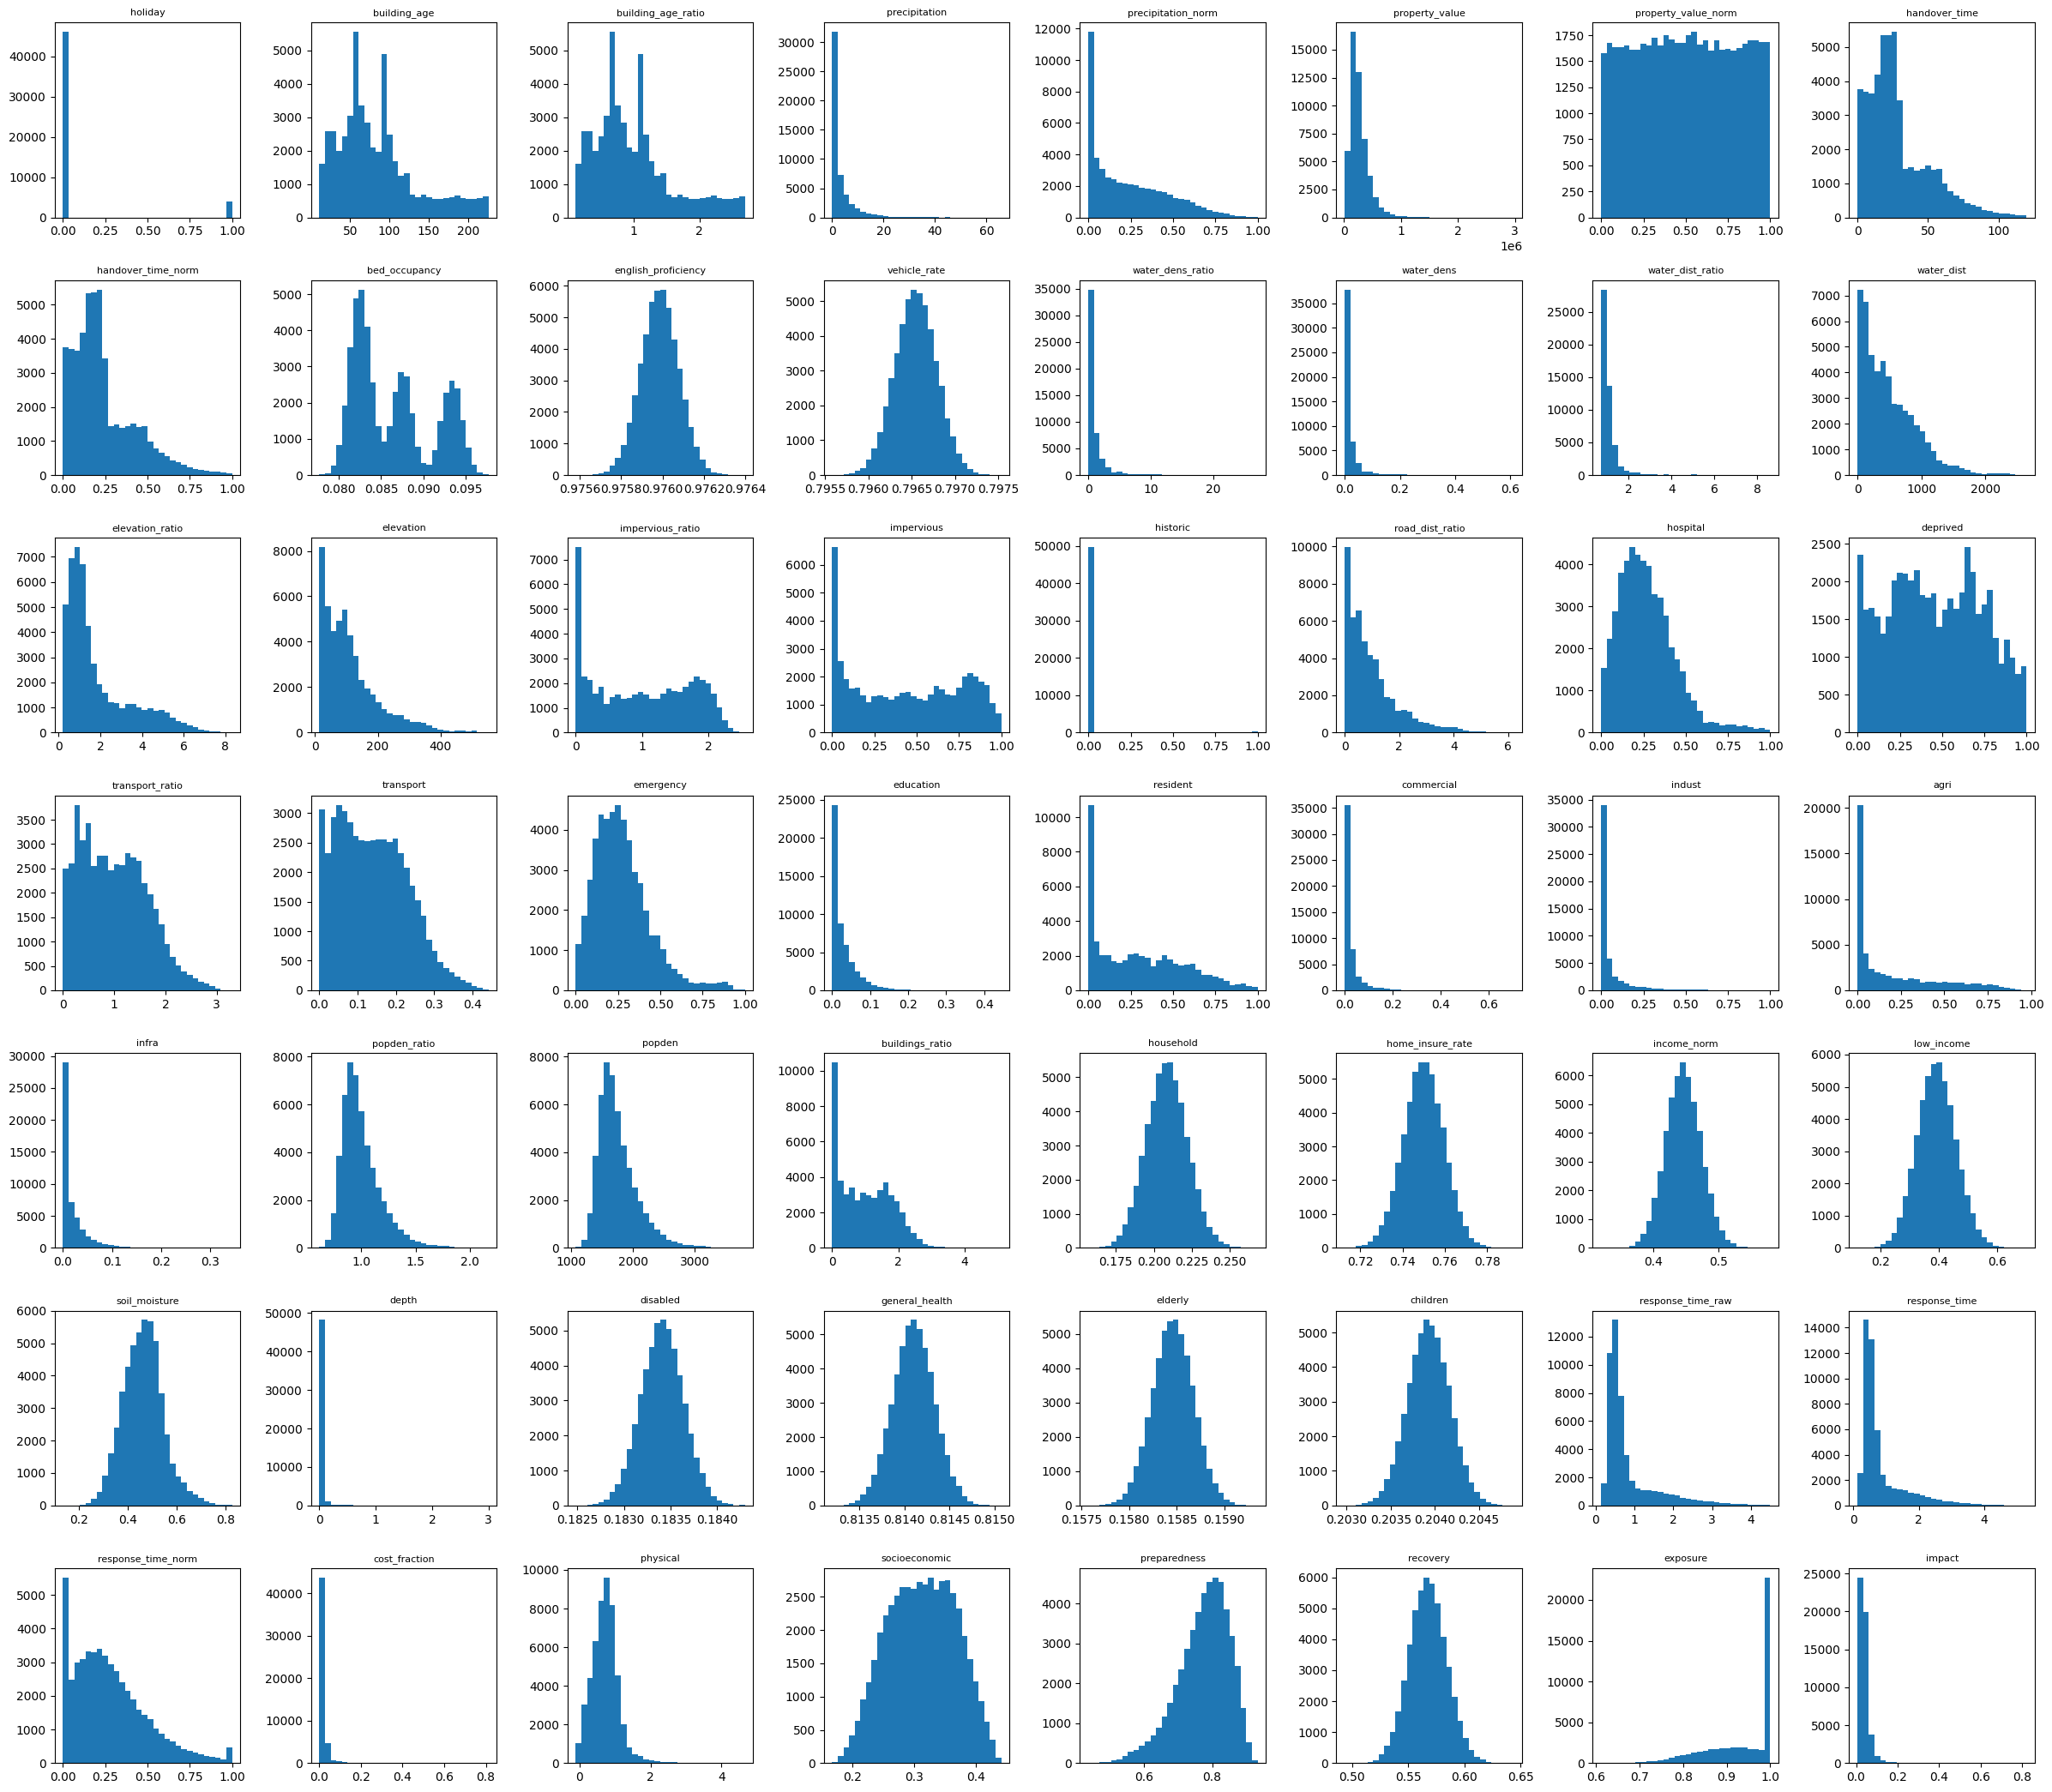

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import math

df = pd.read_csv("samples.csv")

# calculate grid size based on number of columns
n = len(df.columns)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=8)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
#plt.savefig('histograms-200k.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()
